# Metropolis–Hastings algorithm

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Toy example
We want to simulate $X \sim \mathcal{N}(0,1)$ from $U \sim \mathcal{U}([-a,a])$ for different values of $a$.

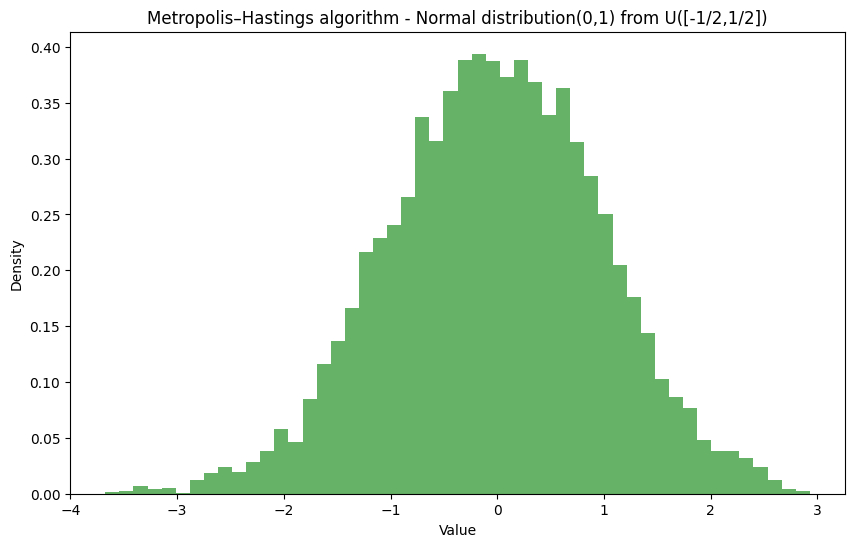

Mean: -0.028136439446575925  | Variance: 0.9924535980144498  | Acceptance rate: 90.05 %


In [4]:
def metropolis_normal_uniform(n_samples, width = 1):
    x = np.zeros(n_samples)
    x[0] = np.random.uniform(-3,3)
    for i in range(1, n_samples):
        y = np.random.uniform(-width/2, width/2)  + x[i-1]
        v = np.random.uniform(0, 1)
        rho = np.exp( 0.5 * (x[i-1] ** 2 - y ** 2) )
        if v < rho:
            x[i] = y
        else:
            x[i] = x[i-1]
    return x

samples = metropolis_normal_uniform(n_samples = 10000, width=1)
plt.figure(figsize=(10,6))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
plt.title('Metropolis–Hastings algorithm - Normal distribution(0,1) from U([-1/2,1/2])' )
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()
print("Mean:", np.mean(samples), " | Variance:", np.var(samples), " | Acceptance rate:", np.round(np.mean(np.diff(samples) != 0)*100,2), "%")

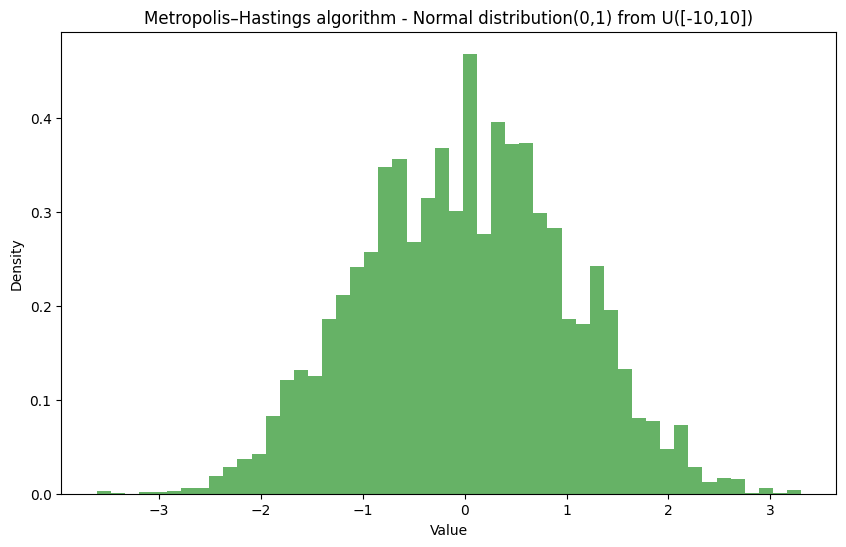

Mean: 0.009185994788746016  | Variance: 1.0273887845857512  | Acceptance rate: 16.34 %


In [5]:
samples = metropolis_normal_uniform(n_samples = 10000, width=20)
plt.figure(figsize=(10,6))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
plt.title('Metropolis–Hastings algorithm - Normal distribution(0,1) from U([-10,10])' )
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()
print("Mean:", np.mean(samples), " | Variance:", np.var(samples), " | Acceptance rate:", np.round(np.mean(np.diff(samples) != 0)*100,2), "%")

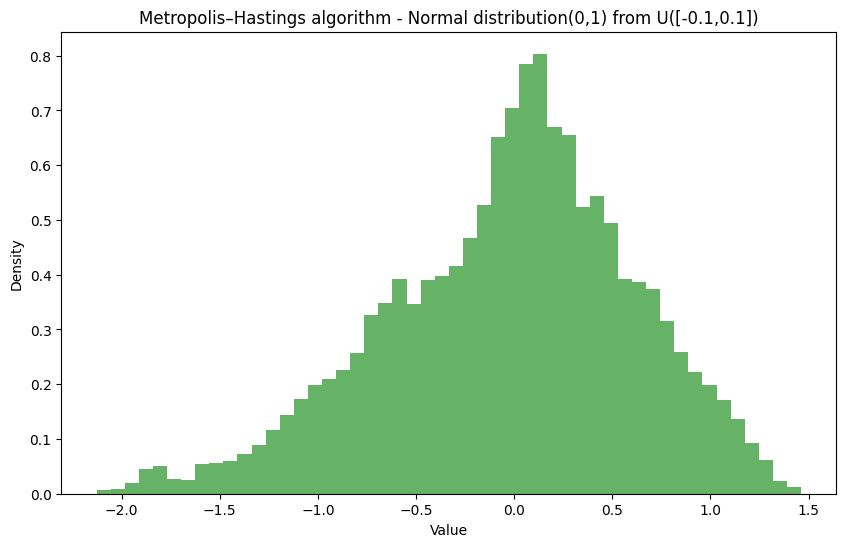

Mean: -0.025833928504457593  | Variance: 0.4035058777390066  | Acceptance rate: 98.59 %


In [6]:
samples = metropolis_normal_uniform(n_samples = 10000, width=0.2)
plt.figure(figsize=(10,6))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
plt.title('Metropolis–Hastings algorithm - Normal distribution(0,1) from U([-0.1,0.1])' )
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()
print("Mean:", np.mean(samples), " | Variance:", np.var(samples), " | Acceptance rate:", np.round(np.mean(np.diff(samples) != 0)*100,2), "%")

## Metropolis versus Rejection Sampling

### Metropolis–Hastings algorithm from $\mathcal{N}([0,0], \sigma ^ 2 I)$

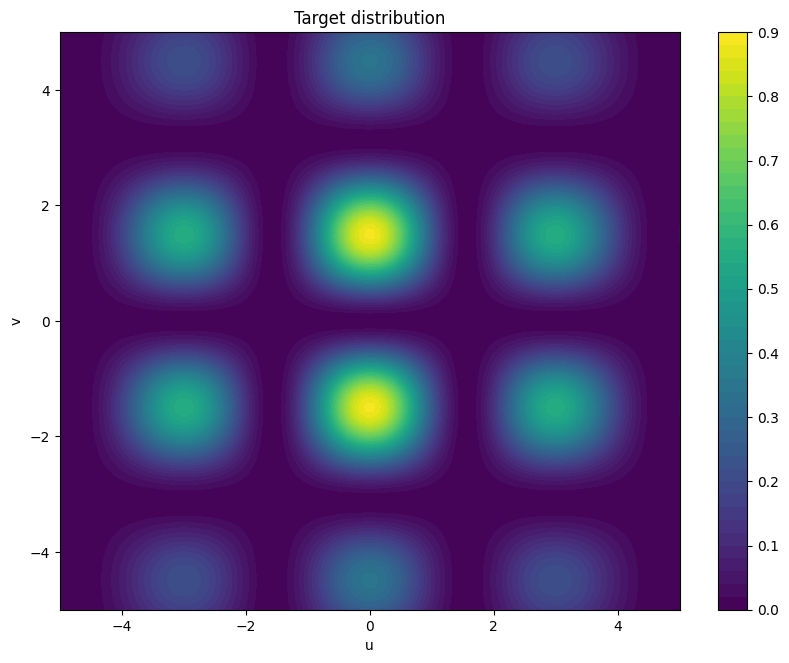

In [7]:
def f(u,v):
    return (np.cos(u) ** 2) * (np.sin(v) ** 2) * np.exp( -0.05 * (u**2 + v**2) )

plt.figure(figsize=(10,7.5))
u = np.linspace(-5, 5, 100)
v = np.linspace(-5, 5, 100)
U, V = np.meshgrid(u, v)
Z = f(U, V)
plt.contourf(U, V, Z, levels=50, cmap='viridis')
plt.colorbar()
plt.title('Target distribution')
plt.xlabel('u')
plt.ylabel('v')
plt.show()

/tmp/ipykernel_20567/580664195.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  rho = min(1,f(y[0], y[1]) / f(samples[i-1][0], samples[i-1][1]))


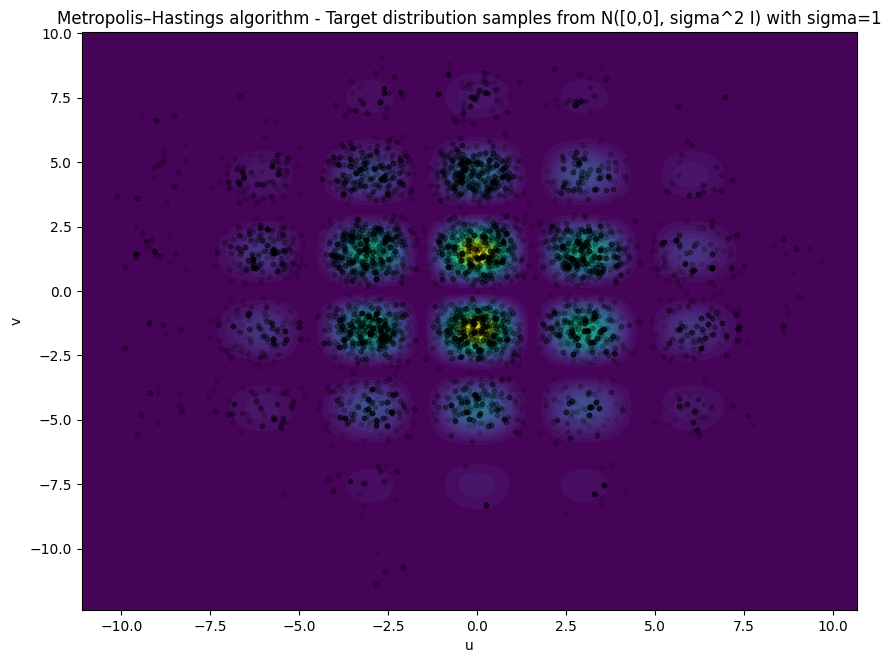

Acceptance rate: 99.99 %


In [8]:
def metropolis_cos_sin_exp_normal(n_samples, sigma = 1):
    samples = np.zeros((n_samples, 2))
    samples[0] = np.array([0,0]).T
    for i in range(1, n_samples):
        y = np.random.normal(loc=samples[i-1], scale=sigma)
        v = np.random.uniform(0, 1)
        rho = min(1,f(y[0], y[1]) / f(samples[i-1][0], samples[i-1][1]))
        if v < rho:
            samples[i] = y
        else:
            samples[i] = samples[i-1]
    return samples

samples = metropolis_cos_sin_exp_normal(n_samples=10000, sigma=1)
plt.figure(figsize=(10,7.5))
u = np.linspace(np.min(samples[:,0]) - 1, np.max(samples[:,0]) + 1, 100)
v = np.linspace(np.min(samples[:,1]) - 1, np.max(samples[:,1]) + 1, 100)
U, V = np.meshgrid(u, v)
Z = f(U, V)
plt.contourf(U, V, Z, levels=50, cmap='viridis')
plt.scatter(samples[:,0], samples[:,1], alpha=0.1, s=10, color='black')
plt.title('Metropolis–Hastings algorithm - Target distribution samples from N([0,0], sigma^2 I) with sigma=1')
plt.xlabel('u')
plt.ylabel('v')
plt.show()
print("Acceptance rate:", np.round(np.mean(np.diff(samples) != 0)*100,2), "%")

/tmp/ipykernel_20567/580664195.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  rho = min(1,f(y[0], y[1]) / f(samples[i-1][0], samples[i-1][1]))


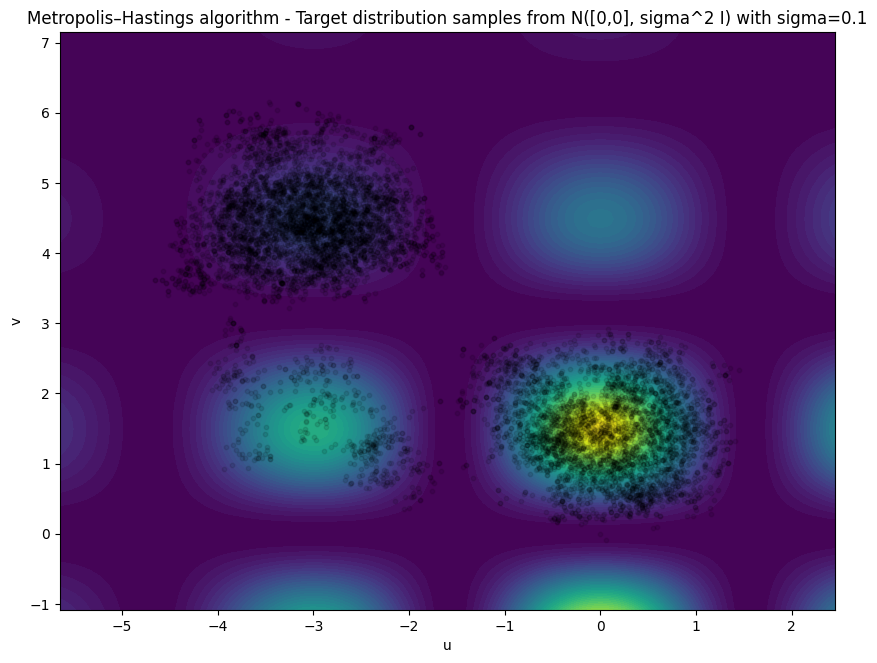

Acceptance rate: 99.99 %


In [9]:
samples = metropolis_cos_sin_exp_normal(n_samples=10000, sigma=0.1)
plt.figure(figsize=(10,7.5))
u = np.linspace(np.min(samples[:,0]) - 1, np.max(samples[:,0]) + 1, 100)
v = np.linspace(np.min(samples[:,1]) - 1, np.max(samples[:,1]) + 1, 100)
U, V = np.meshgrid(u, v)
Z = f(U, V)
plt.contourf(U, V, Z, levels=50, cmap='viridis')
plt.scatter(samples[:,0], samples[:,1], alpha=0.1, s=10, color='black')
plt.title('Metropolis–Hastings algorithm - Target distribution samples from N([0,0], sigma^2 I) with sigma=0.1')
plt.xlabel('u')
plt.ylabel('v')
plt.show()
print("Acceptance rate:", np.round(np.mean(np.diff(samples) != 0)*100,2), "%")

### Rejection sampling

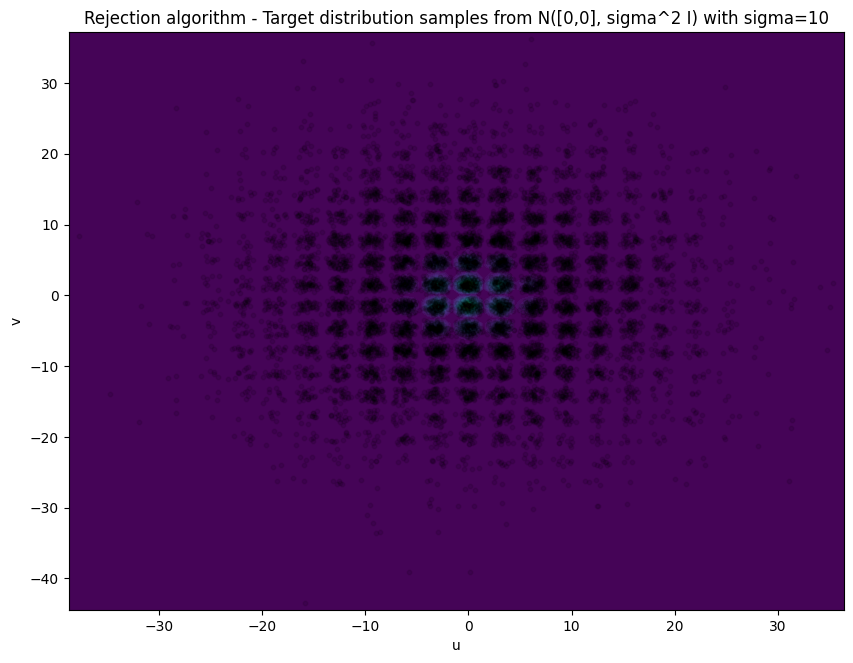

In [11]:
def rejection_gaussian(n_samples, sigma=10):
    samples = np.zeros((n_samples, 2))
    count = 0
    while count < n_samples:
        y = np.random.normal(loc = [0,0], scale = sigma)
        t = np.random.uniform(0, 1)
        if t < (np.cos(y[0]) ** 2) * (np.sin(y[1]) ** 2):
            samples[count] = y
            count += 1
    return samples

samples = rejection_gaussian(n_samples=10000, sigma=10)
plt.figure(figsize=(10,7.5))
u = np.linspace(np.min(samples[:,0]) - 1, np.max(samples[:,0]) + 1, 100)
v = np.linspace(np.min(samples[:,1]) - 1, np.max(samples[:,1]) + 1, 100)
U, V = np.meshgrid(u, v)
Z = f(U, V)
plt.contourf(U, V, Z, levels=50, cmap='viridis')
plt.scatter(samples[:,0], samples[:,1], alpha=0.1, s=10, color='black')
plt.title('Rejection algorithm - Target distribution samples from N([0,0], sigma^2 I) with sigma=10')
plt.xlabel('u')
plt.ylabel('v')
plt.show()